In [2]:
import matplotlib.pyplot as plt
import cv2

Dataset for Automatic Region-based Coronary Artery Disease Diagnostics Using X-Ray Angiography Images: 
https://www.nature.com/articles/s41597-023-02871-z

In [ ]:
!wget -O downloads/arcade.zip "https://zenodo.org/records/10390295/files/arcade.zip"
!mkdir -p raw_datasets
!unzip downloads/arcade.zip -d raw_datasets/arcade



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://zenodo.org/records/103]87Saving 'downloads/arcade.zip'
87downloads/arcade.zip   0% [>                             ]    3.86M    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/arcade.zip   2% [>                             ]   10.47M    6.61MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/arcade.zip   3% [>                             ]   15.29M    5.71MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/arcade.zip   4% [>                             ]   20.28M    5.47MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/arcade.zip   5% [>                             ]   24.30M    5.11MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/arcade.zip   6% [>                             ]   27.25M    4.67MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/arcade.zip   6% [=>                            ]   29.99M    4.35MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/arcade.zip 

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Selected image_id: 1
Image info: {'id': 1, 'width': 512, 'height': 512, 'file_name': '1.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
Annotation IDs: [1]
Annotations:
{'id': 1, 'image_id': 1, 'category_id': 26, 'segmentation': [[229.53, 236.06, 236.6, 248.0, 249.1, 267.7, 257.46, 286.28, 269.05, 278.85, 261.9, 263.4, 252.1, 245.5, 244.09, 236.06, 240.22, 230.42]], 'area': 768.0, 'bbox': [229.53, 230.42, 39.52, 55.86], 'iscrowd': 0, 'attributes': {'occluded': False}}
ann.image_id == selected? True


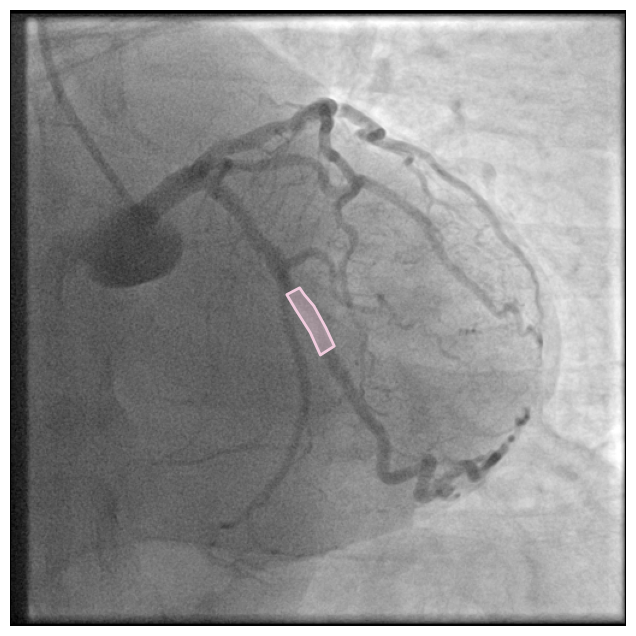

In [5]:
from pycocotools.coco import COCO
import os

# na zbiorze train ten kod nie zadziala ponieważ z jakiegos powodu id annotacji są zduplikowane
ROOT = "raw_datasets/arcade/arcade/stenosis/test"
IMG_DIR = os.path.join(ROOT, "images")
ANN_FILE = os.path.join(ROOT, "annotations", "test.json")

coco = COCO(ANN_FILE)

img_id = coco.getImgIds()[0]
print("Selected image_id:", img_id)

img_info = coco.loadImgs([img_id])[0]
print("Image info:", img_info)

img = cv2.imread(os.path.join(IMG_DIR, img_info["file_name"]), cv2.IMREAD_GRAYSCALE)

ann_ids = coco.getAnnIds(imgIds=[img_id])
print("Annotation IDs:", ann_ids)

anns = coco.loadAnns(ann_ids)
print("Annotations:")
for ann in anns:
    print(ann)
    print("ann.image_id == selected?", ann["image_id"] == img_id)

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")
plt.axis("off")
coco.showAnns(anns)
plt.show()

Database X-ray Coronary Angiograms (DCA1): http://personal.cimat.mx:8181/~ivan.cruz/DB_Angiograms.html lub https://www.kaggle.com/datasets/bard2024/database-x-ray-coronary-angiograms-dca1

In [19]:
!wget -O downloads/DCA1.zip "http://personal.cimat.mx:8181/~ivan.cruz/DB_Angiograms_files/DB_Angiograms_134.zip"
!unzip downloads/DCA1.zip -d raw_datasets/DCA1



7[Files: 0  Bytes: 0  [0 B/s] Re]87[http://personal.cimat.mx:8181/]87Saving 'downloads/DCA1.zip'
87downloads/DCA1.zip     1% [>                             ]  122.66K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/DCA1.zip    10% [==>                           ]  974.74K  852.08KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/DCA1.zip    50% [==============>               ]    4.49M    2.18MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87downloads/DCA1.zip   100% [=============================>]    8.97M    3.48MB/s87HTTP response 200 OK [http://personal.cimat.mx:8181/~ivan.cruz/DB_Angiograms_files/DB_Angiograms_134.zip]
87downloads/DCA1.zip   100% [=============================>]    8.97M    3.48MB/s87[Files: 1  Bytes: 8.97M [2.53MB]8Archive:  downloads/DCA1.zip
  inflating: raw_datasets/DCA1/Database_134_Angiograms/1.pgm  
  inflating: raw_datasets/DCA1/Database_134_Angiograms/1_gt.pgm  
  inflating: raw_datasets/DCA1/Database_134_Angiograms/10.pgm  
  i

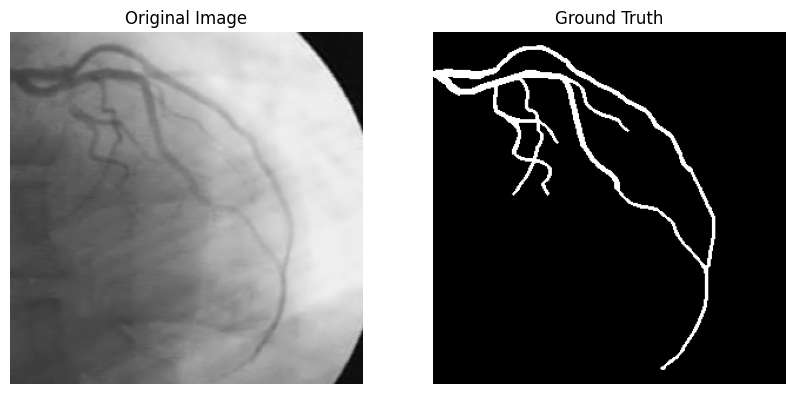

In [20]:
image = cv2.imread(
    "raw_datasets/DCA1/Database_134_Angiograms/2.pgm", cv2.IMREAD_GRAYSCALE
)
image_gt = cv2.imread(
    "raw_datasets/DCA1/Database_134_Angiograms/2_gt.pgm", cv2.IMREAD_GRAYSCALE
)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(image_gt, cmap="gray")
axs[1].set_title("Ground Truth")
axs[1].axis("off")
plt.show()

CoronaryDominance: Angiogram dataset for coronary dominance classification: https://huggingface.co/datasets/BearSubj13/CoronaryDominance

In [1]:
from datasets import load_dataset

ds = load_dataset("BearSubj13/CoronaryDominance")

In [4]:
ds

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 1
    })
})